# Setup
## Import and Graphs

In [6]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Colour convention used throughout this notebook:
#   more massive BH = dark red, less massive BH = blue, everything together = black
#   common-envelope channel = orange, stable-mass-transfer channel = teal
C1, C2, CSYS = "#C1272D", "#0B5FA5", "#222222"
C_CE, C_SMT = "#E07B39", "#2A9D8F"


def weighted_median(x, w):
    '''Median of x where each entry carries a statistical weight w (see section 1.4).'''
    order = np.argsort(np.asarray(x))
    x_sorted = np.asarray(x)[order]
    cum_w = np.cumsum(np.asarray(w)[order])
    return x_sorted[np.searchsorted(cum_w, 0.5 * cum_w[-1])]


DATA_PATH = Path("../../../data/COMPAS_Output_wWeights.h5")

print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__)

numpy 2.5.1 | h5py 3.16.0 | pandas 3.0.5


## Load Data and Show

In [7]:
with h5py.File(DATA_PATH, "r") as f:
    for group in f.keys():
        n_rows = f[group][list(f[group].keys())[0]].shape[0]
        print(f"\nGroup {group}   ({n_rows:,} rows)")
        print("   " + "-" * 66)
        for col in f[group].keys():
            d = f[group][col] 
            print(f"   {col}: {d.shape[0]:,} rows")


Group BSE_Double_Compact_Objects   (2,523,122 rows)
   ------------------------------------------------------------------
   CE_Event_Counter: 2,523,122 rows
   Coalescence_Time: 2,523,122 rows
   Immediate_RLOF>CE: 2,523,122 rows
   MT_Donor_Hist(1): 2,523,122 rows
   MT_Donor_Hist(2): 2,523,122 rows
   Mass(1): 2,523,122 rows
   Mass(2): 2,523,122 rows
   Merges_Hubble_Time: 2,523,122 rows
   Metallicity@ZAMS(1): 2,523,122 rows
   Optimistic_CE: 2,523,122 rows
   SEED: 2,523,122 rows
   Stellar_Type(1): 2,523,122 rows
   Stellar_Type(2): 2,523,122 rows
   Time: 2,523,122 rows
   mixture_weight: 2,523,122 rows

Group BSE_RLOF   (31,878,423 rows)
   ------------------------------------------------------------------
   CEE>MT: 31,878,423 rows
   Eccentricity<MT: 31,878,423 rows
   Eccentricity>MT: 31,878,423 rows
   MT_Event_Counter: 31,878,423 rows
   Mass(1)<MT: 31,878,423 rows
   Mass(1)>MT: 31,878,423 rows
   Mass(2)<MT: 31,878,423 rows
   Mass(2)>MT: 31,878,423 rows
   RLOF(1)>MT:

## Filter the Data

In [8]:
DCO_COLUMNS = [
    "SEED",
    "Mass(1)", "Mass(2)",
    "Stellar_Type(1)", "Stellar_Type(2)",
    "Merges_Hubble_Time", "Coalescence_Time", "Time",
    "Metallicity@ZAMS(1)", "CE_Event_Counter",
    "mixture_weight",
]

with h5py.File(DATA_PATH, "r") as f:
    dco = pd.DataFrame({c: f["BSE_Double_Compact_Objects"][c][()] for c in DCO_COLUMNS})
    n_binaries_simulated = f["BSE_System_Parameters"]["SEED"].shape[0]

dco = dco.rename(columns={
    "Mass(1)": "M1_raw", "Mass(2)": "M2_raw",
    "Stellar_Type(1)": "type1", "Stellar_Type(2)": "type2",
    "Metallicity@ZAMS(1)": "Z",
    "Merges_Hubble_Time": "merges", "Coalescence_Time": "t_coal_Myr",
    "Time": "t_form_Myr", "CE_Event_Counter": "n_CE", "mixture_weight": "w",
})

print(f"binaries simulated in total   : {n_binaries_simulated:,}")
print(f"double compact objects formed : {len(dco):,}"
      f"   ({100 * len(dco) / n_binaries_simulated:.2f}% of all binaries)")
print(f"memory used by our table      : {dco.memory_usage(deep=True).sum() / 1e6:.0f} MB")
dco.head()

binaries simulated in total   : 10,000,000
double compact objects formed : 2,523,122   (25.23% of all binaries)
memory used by our table      : 174 MB


,SEED,M1_raw,M2_raw,type1,type2,merges,t_coal_Myr,t_form_Myr,Z,n_CE,w
0,53,17.013836,16.985069,14,14,0,9.133827e+15,5.466165,0.000212,0,3.921569
1,55,14.970078,12.344720,14,14,1,9.987571e+00,6.276184,0.000353,1,0.003438
2,220,42.781140,33.955125,14,14,0,1.059965e+06,5.630744,0.000157,0,3.921408
3,386,38.245214,37.461885,14,14,0,1.402914e+17,3.821612,0.000218,0,3.921569
4,444,16.172687,15.664367,14,14,0,1.932570e+20,5.652540,0.000432,0,3.921569


# Selecting the merging Binary Black Holes

In [9]:
BH, NS = 14, 13   # Hurley et al. (2000) stellar type codes

is_bh1, is_bh2 = dco.type1 == BH, dco.type2 == BH
dco["is_BBH"]  = is_bh1 & is_bh2
dco["is_BHNS"] = is_bh1 ^ is_bh2          # exclusive-or: exactly one is a BH
dco["is_BNS"]  = (dco.type1 == NS) & (dco.type2 == NS)

# order the masses so that m1 >= m2, regardless of which star was born heavier
dco["m1"] = np.maximum(dco.M1_raw, dco.M2_raw)
dco["m2"] = np.minimum(dco.M1_raw, dco.M2_raw)
dco["q"]  = dco.m2 / dco.m1                                       # mass ratio, 0 < q <= 1
dco["Mtot"] = dco.m1 + dco.m2
dco["Mchirp"] = (dco.m1 * dco.m2) ** 0.6 / dco.Mtot ** 0.2        # chirp mass

# --- the census, counted BOTH ways so you can see the difference ----------------
print(f"{'type':10s} {'raw rows':>12s} {'raw %':>8s} {'weighted':>12s} {'weighted %':>11s}")
print("-" * 58)
wtot = dco.w.sum()
for name, mask in [("BH+BH", dco.is_BBH), ("BH+NS", dco.is_BHNS), ("NS+NS", dco.is_BNS)]:
    print(f"{name:10s} {mask.sum():12,} {100*mask.mean():7.2f}% "
          f"{dco.w[mask].sum():12,.0f} {100*dco.w[mask].sum()/wtot:10.2f}%")
print("-" * 58)
print(f"{'TOTAL':10s} {len(dco):12,} {100.0:7.2f}% {wtot:12,.0f} {100.0:10.2f}%")

# --- and now our sample ---------------------------------------------------------
bbh = dco[dco.is_BBH & (dco.merges == 1)].copy()
print(f"\nMerging binary black holes: {len(bbh):,} rows, {bbh.w.sum():,.0f} in weighted units")
print(f"Fraction of all binary black holes that merge within a Hubble time:")
print(f"   counting rows  : {100 * len(bbh) / dco.is_BBH.sum():.1f}%")
print(f"   summing weights: {100 * bbh.w.sum() / dco.w[dco.is_BBH].sum():.1f}%   <-- the real answer")

type           raw rows    raw %     weighted  weighted %
----------------------------------------------------------
BH+BH         2,273,376   90.10%      117,689      78.87%
BH+NS           244,410    9.69%       12,315       8.25%
NS+NS             5,336    0.21%       19,217      12.88%
----------------------------------------------------------
TOTAL         2,523,122  100.00%      149,220     100.00%

Merging binary black holes: 1,640,550 rows, 14,911 in weighted units
Fraction of all binary black holes that merge within a Hubble time:
   counting rows  : 72.2%
   summing weights: 12.7%   <-- the real answer


# Exercise 1
## Total Mass Distribution

In [10]:
# Maryam's Code of Analysis
# How many systems survive above various total masses?

thresholds = [60, 80, 90, 100, 120, 130, 140, 150, 160, 170, 180, 190, 200]

total_rows = len(bbh)
total_weight = bbh.w.sum()

print(f"\nTotal number of merging BBHs: {total_rows:,} rows")
print("\nTotal-mass tail statistics")
print("-" * 65)
print(f"{'Mtot threshold':<15} {'Rows':>10} {'Weighted':>15} {'Weighted %':>15}")
print("-" * 65)

for mcut in thresholds:
    mask = bbh.Mtot > mcut

    rows = mask.sum()
    weighted = bbh.w[mask].sum()
    weighted_pct = 100 * weighted / total_weight

    print(
        f">{mcut:<13}"
        f"{rows:>10,d}"
        f"{weighted:>15.2f}"
        f"{weighted_pct:>14.4f}%"
    )


Total number of merging BBHs: 1,640,550 rows

Total-mass tail statistics
-----------------------------------------------------------------
Mtot threshold        Rows        Weighted      Weighted %
-----------------------------------------------------------------
>60               30,199         585.80        3.9286%
>80                5,563         144.70        0.9704%
>90                  664          19.79        0.1327%
>100                  19           0.38        0.0025%
>120                  19           0.38        0.0025%
>130                  19           0.38        0.0025%
>140                  19           0.38        0.0025%
>150                  18           0.26        0.0017%
>160                  18           0.26        0.0017%
>170                  18           0.26        0.0017%
>180                  11           0.21        0.0014%
>190                   0           0.00        0.0000%
>200                   0           0.00        0.0000%


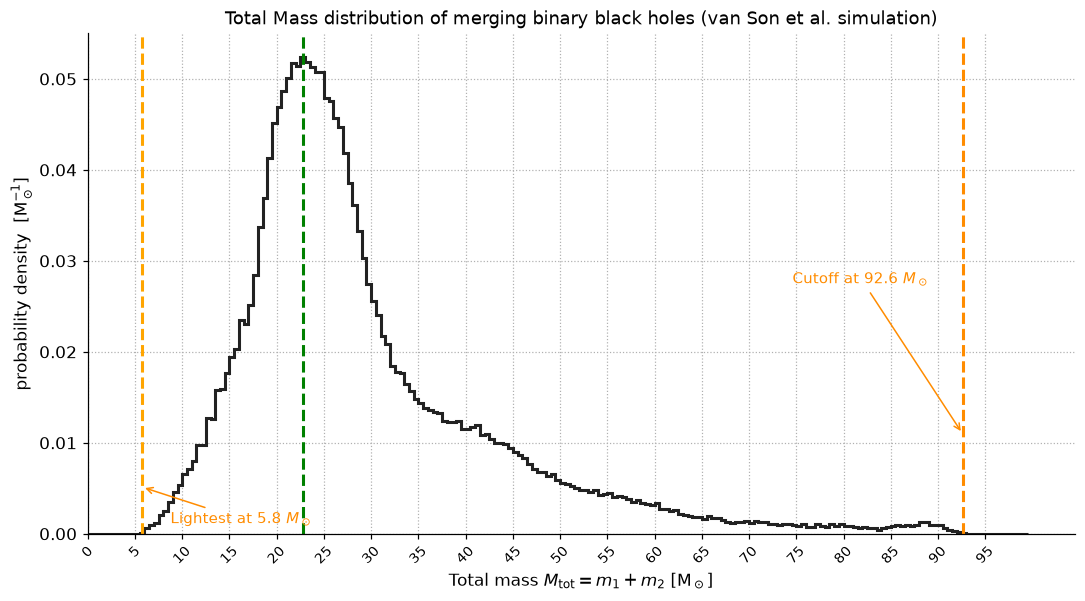

In [13]:
# Define bins
bins = np.arange(0, 100, 0.5)

# Plot histogram
fig, ax = plt.subplots(figsize=(10, 5.6))

hist, edges, _ = ax.hist( bbh.Mtot, bins=bins, weights=bbh.w, density=True, 
        histtype="step", linewidth=2, color=CSYS)

# Start of Distribution
nonzero = np.where(hist > 0)[0]
first_bin = nonzero[0]
last_bin = nonzero[-1]
start = edges[first_bin]
start_mass = 0.5 * (edges[first_bin] + edges[first_bin+1])
ax.axvline(start_mass, color="orange", linestyle="--", linewidth=2, label=f"Lightest = {start_mass:.1f} $M_\\odot$")
ax.annotate(f"Lightest at {start_mass:.1f} $M_\\odot$",
            xy=(start_mass, hist[first_bin] + 0.005),
            xytext=(start_mass + 3, hist[first_bin]+0.001),
            arrowprops=dict(arrowstyle="->", color="darkorange"), 
            color="darkorange", fontsize=10)

# Peak of the distribution
peak_idx = np.argmax(hist)
peak_mass = 0.5 * (edges[peak_idx] + edges[peak_idx + 1])
ax.axvline( peak_mass, color="green", linestyle="--", linewidth=2, label=f"Peak ≈ {peak_mass:.1f} $M_\\odot$")
ax.annotate(f"Peak at {peak_mass:.1f} $M_\\odot$", 
            xy=(peak_mass, hist[peak_idx] + 0.005), 
            xytext=(peak_mass + 6, hist[peak_idx]*0.9), 
            arrowprops=dict(arrowstyle="->", color="green"), 
            color="green", fontsize=10)

# Pair-instability cutoff
cutoff = edges[last_bin + 1]
cutoff = 92.6

ax.axvline(cutoff, color="darkorange", linestyle="--", linewidth=2, label=f"Cutoff = {cutoff:.1f} $M_\\odot$")
ax.annotate(f"Cutoff at {cutoff:.1f} $M_\\odot$", 
            xy=(cutoff, ax.get_ylim()[1]*0.2), 
            xytext=(cutoff-18, ax.get_ylim()[1]*0.5), 
            arrowprops=dict(arrowstyle="->", color="darkorange"), 
            color="darkorange", fontsize=10)

ax.set_xticks(range(0, 100, 5))
ax.tick_params(axis='x', rotation=45, labelsize=9)
# ax.set_xlim(0, 52)
# ax.set_ylim(2e-4, 0.4)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Total mass $M_{\rm tot} = m_1 + m_2$ [M$_\odot$]")
ax.set_ylabel(r"probability density  [M$_\odot^{-1}$]")
ax.set_title("Total Mass distribution of merging binary black holes (van Son et al. simulation)", fontsize=12)

plt.tight_layout()
plt.grid(True, alpha=1)
plt.show()

### **Discussion**

The main $M_{tot}$ distribution cuts off at $92.5M_{\odot}$ and the PISN limit states that for individual BH masses, the stellar evolution produces maximum BH mass around $m_{\rm BH,max}\sim 45-46 M_\odot.$ For an equal-mass BH can have $M_{\rm tot} \sim 46+46 = 92M_\odot$, which matches our result.

Another result to notice is that, the $M_{tot}$ cutoff is more gradual unlike the sharp cutoff in $m_1$ since $M_{tot}$ is the sum of two masses. Some mass systems extends the distribution to $\sim 185M_{\odot}$

# Exercise 2

## Delay Times

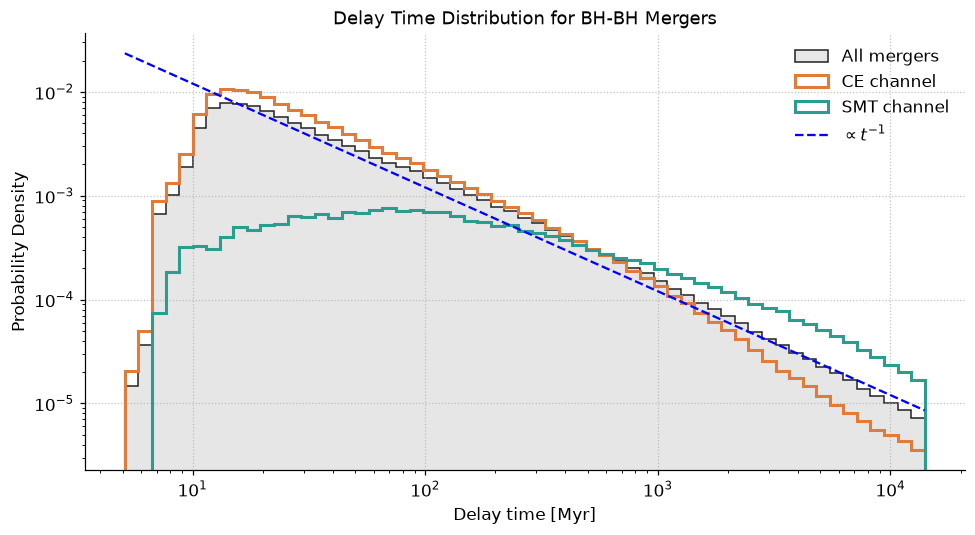

In [14]:
fig, ax = plt.subplots(figsize=(9,5))

bbh["t_delay_Myr"] = bbh.t_form_Myr + bbh.t_coal_Myr

# Bins
t_bins = np.logspace(np.log10(bbh.t_delay_Myr.min()), np.log10(bbh.t_delay_Myr.max()), 60)

# Plot of All BBH Mergers
ax.hist(bbh.t_delay_Myr, bins=t_bins, weights=bbh.w, density=True,
        histtype="stepfilled", color="0.9", edgecolor=CSYS, label='All mergers')

ce_mask  = bbh.n_CE >= 1      # went through at least one common envelope
smt_mask = bbh.n_CE == 0      # never had one: only stable mass transfer

# CE Channel
ax.hist(bbh.loc[ce_mask, "t_delay_Myr"], bins=t_bins, weights=bbh.loc[ce_mask, "w"], 
        density=True, histtype="step", linewidth=2, color = C_CE, label="CE channel")

# Stable mass-transfer channel
ax.hist( bbh.loc[smt_mask, "t_delay_Myr"], bins=t_bins, weights=bbh.loc[smt_mask, "w"], 
        density=True, histtype="step", linewidth=2, color = C_SMT,  label="SMT channel")

# t^-1 reference line
t = np.logspace(np.log10(bbh.t_delay_Myr.min()), np.log10(bbh.t_delay_Myr.max()), 200)
ax.plot(t, 0.12/t, '--', color='blue', label=r"$\propto t^{-1}$")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Delay time [Myr]")
ax.set_ylabel("Probability Density")
ax.set_title("Delay Time Distribution for BH-BH Mergers", fontsize=12)

ax.legend()
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

### **Discussion**

The CE (Common Envelope) Channel mergers sooner than the SMT (Stable Mass Transfer) Channel. Which actually matches with the discussion of Part 5 because common-envelope phase removes orbital energy and angular momentum, shrinking the separation. And the merge time is directly related to separation as: 
$$ t_{merge} \propto a^4 $$
even a slight reduction in separation leads to much shorter merger time.

After the normalization, the delay time distribution does follow the power rule $\propto t^{-1}$ roughly. Deviations are seen at very short delay times, where stellar evolution sets a minimum time before black holes can form.

# Exercise 3

## Neutron Star Plot 
Maryam's codes helped a lot!! 

In [15]:
# Required dataset

# Black hole - neutron star binaries merging
bhns = dco[dco.is_BHNS & (dco.merges == 1)].copy()

# BNS merging
bns = dco[dco.is_BNS & (dco.merges == 1)].copy()

print(f"\nMerging black hole - neutron star binaries: {len(bhns):,} rows, {bhns.w.sum():,.0f} in weighted units")
print(f"   counting rows  : {100 * len(bhns) / dco.is_BHNS.sum():.1f}%")
print(f"   summing weights: {100 * bhns.w.sum() / dco.w[dco.is_BHNS].sum():.1f}% (of real population)")

print()

print(f"\nMerging binary neutron stars: {len(bns):,} rows, {bns.w.sum():,.0f} in weighted units")
print(f"   counting rows  : {100 * len(bns) / dco.is_BNS.sum():.1f}%")
print(f"   summing weights: {100 * bns.w.sum() / dco.w[dco.is_BNS].sum():.1f}% (of real population)")


Merging black hole - neutron star binaries: 192,673 rows, 2,918 in weighted units
   counting rows  : 78.8%
   summing weights: 23.7% (of real population)


Merging binary neutron stars: 1,922 rows, 6,508 in weighted units
   counting rows  : 36.0%
   summing weights: 33.9% (of real population)


In [16]:
# Dataframes for BHNS and BNS

# -- Neutron Star masses and weights--

# BNS: both components are neutron stars
ns_mass_bns = np.concatenate([bns.m1.values, bns.m2.values])
ns_weight_bns = np.concatenate([bns.w.values, bns.w.values])

# BHNS: select the neutron star component
ns_mass_bhns = np.concatenate([
    bhns.loc[bhns.type1 == NS, "M1_raw"],
    bhns.loc[bhns.type2 == NS, "M2_raw"],
])
ns_weight_bhns = np.concatenate([
    bhns.loc[bhns.type1 == NS, "w"],
    bhns.loc[bhns.type2 == NS, "w"],
])

# All neutron stars
ns_masses = np.concatenate([ns_mass_bns, ns_mass_bhns])
ns_weights = np.concatenate([ns_weight_bns, ns_weight_bhns])

# -- Black hole masses and weights --

# Black hole masses in BH-NS binaries

bh_mass_bhns = np.concatenate([
    bhns.loc[bhns.type1 == BH, "M1_raw"],
    bhns.loc[bhns.type2 == BH, "M2_raw"],
])

bh_weight_bhns = np.concatenate([
    bhns.loc[bhns.type1 == BH, "w"],
    bhns.loc[bhns.type2 == BH, "w"],
])

# Black hole masses in BH-BH binaries
bh_mass_bbh = np.concatenate([bbh.m1.values, bbh.m2.values])
bh_weight_bbh = np.concatenate([bbh.w.values, bbh.w.values])

# All BHs
bh_masses = np.concatenate([bh_mass_bbh, bh_mass_bhns])
bh_weights = np.concatenate([bh_weight_bbh, bh_weight_bhns])

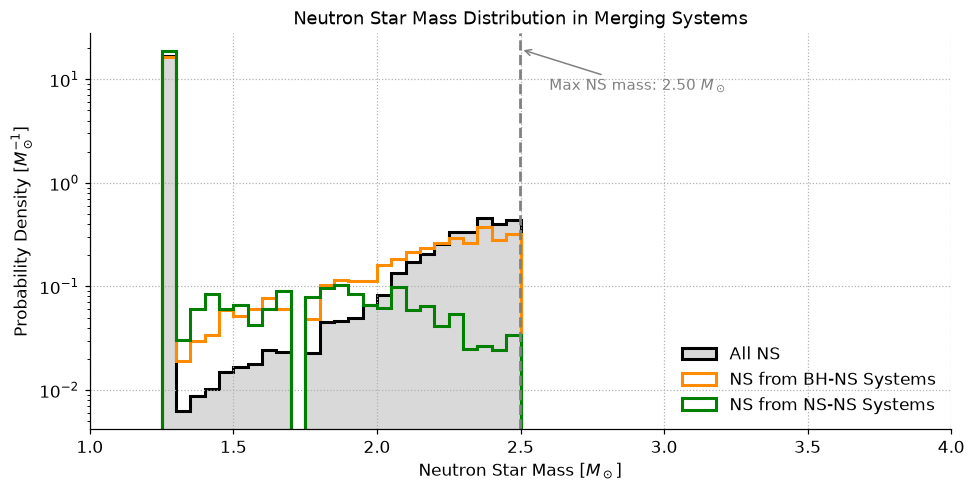

In [17]:
# Histogram for neutron star masses, for BNS and BHNS Separately

fig, ax = plt.subplots(figsize=(9, 4.6))

ns_mass_bins = np.arange(0, 5, 0.05)

ax.hist(ns_masses, bins=ns_mass_bins, density=True, histtype='stepfilled',
        color='0.85', edgecolor='black', linewidth=2, label='All NS')

ax.hist(ns_mass_bhns, bins=ns_mass_bins, weights=ns_weight_bhns, 
        density=True, histtype="step", color="darkorange", linewidth=2, 
        label="NS from BH-NS Systems")

ax.hist(ns_mass_bns, bins=ns_mass_bins, weights=ns_weight_bns, 
        density=True, histtype="step", color="green", linewidth=2, 
        label="NS from NS-NS Systems")

# Max NS mass in BNS systems
max_ns = ns_masses.max()
ax.axvline(max_ns, color='grey', linestyle='--', linewidth=1.8)
ax.annotate(f"Max NS mass: {max_ns:.2f} $M_\\odot$", 
            xy=(max_ns, ax.get_ylim()[1]), 
            xytext=(max_ns + 0.1, ax.get_ylim()[1] * 0.4), 
            arrowprops=dict(arrowstyle="->", color="gray"), 
            color="gray", 
            fontsize=10)

ax.set_xlim(1, 4)
ax.set_yscale("log")
ax.set_xlabel(r"Neutron Star Mass [$M_\odot$]")
ax.set_ylabel(r"Probability Density [$M_\odot^{-1}$]")
ax.set_title("Neutron Star Mass Distribution in Merging Systems", fontsize=12)
ax.legend()
plt.grid(True, alpha=1)
plt.tight_layout()
plt.show()

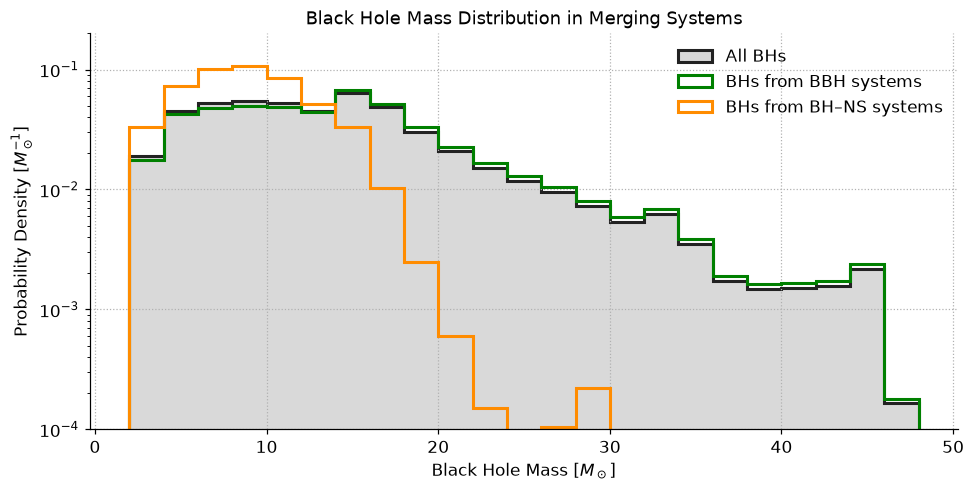

In [62]:
# Histogram for BH mass, separating BBH and BHNS

fig, ax = plt.subplots(figsize=(9, 4.6))

bins = np.arange(2, 50, 2)

ax.hist(bh_masses, bins=bins, weights=bh_weights, density=True,
        histtype="stepfilled", color="0.85", edgecolor=CSYS, linewidth=2, 
        label="All BHs")

ax.hist(bh_mass_bbh, bins=bins,weights=bh_weight_bbh, density=True, 
        histtype="step", color="green", linewidth=2, 
        label="BHs from BBH systems")


ax.hist(bh_mass_bhns, bins=bins, weights=bh_weight_bhns, 
        density=True, histtype="step", color="darkorange", linewidth=2,  
        label="BHs from BH–NS systems")


# Formatting
ax.set_ylim(1e-4, 0.2)
ax.set_yscale("log")
ax.set_xlabel(r"Black Hole Mass [$M_\odot$]")
ax.set_ylabel(r"Probability Density [$M_\odot^{-1}$]")
ax.set_title("Black Hole Mass Distribution in Merging Systems", fontsize=12)

ax.legend()
plt.grid(True, alpha=1)
plt.tight_layout()
plt.show()

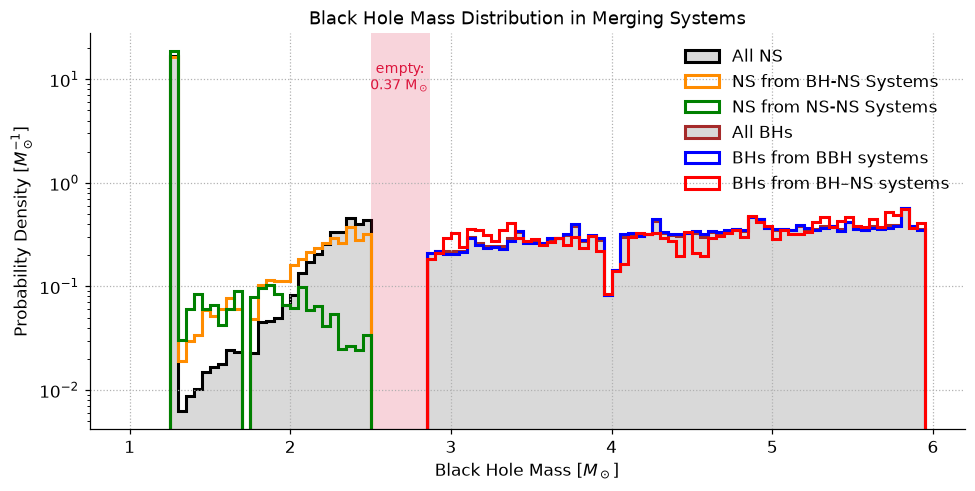

In [63]:
# Comparison by plotting NS and BH mass side by side.

fig, ax = plt.subplots(figsize=(9, 4.6))

zoom_bins = np.arange(1, 6, 0.05)

ax.hist(ns_masses, bins=zoom_bins, density=True, histtype='stepfilled',
        color='0.85', edgecolor='black', linewidth=2, label='All NS')

ax.hist(ns_mass_bhns, bins=zoom_bins, weights=ns_weight_bhns, 
        density=True, histtype="step", color="darkorange", linewidth=2, 
        label="NS from BH-NS Systems")

ax.hist(ns_mass_bns, bins=zoom_bins, weights=ns_weight_bns, 
        density=True, histtype="step", color="green", linewidth=2, 
        label="NS from NS-NS Systems")

ax.hist(bh_masses, bins=zoom_bins, weights=bh_weights, density=True,
        histtype="stepfilled", color="0.85", edgecolor='brown', linewidth=2, 
        label="All BHs")

ax.hist(bh_mass_bbh, bins=zoom_bins,weights=bh_weight_bbh, density=True, 
        histtype="step", color="blue", linewidth=2, 
        label="BHs from BBH systems")

ax.hist(bh_mass_bhns, bins=zoom_bins, weights=bh_weight_bhns, 
        density=True, histtype="step", color="red", linewidth=2,  
        label="BHs from BH–NS systems")

# Pair-instability gap
ax.axvspan(ns_masses.max(), bh_masses.min(), color="crimson", alpha=0.18, lw=0)
ax.text(0.5 * (ns_masses.max() + bh_masses.min()), 0.93,
        f"empty:\n{bh_masses.min() - ns_masses.max():.2f} M$_\\odot$", color="crimson",
        fontsize=9, ha="center", va="top", transform=ax.get_xaxis_transform())

# Formatting
ax.set_yscale("log")
ax.set_xlabel(r"Black Hole Mass [$M_\odot$]")
ax.set_ylabel(r"Probability Density [$M_\odot^{-1}$]")
ax.set_title("Black Hole Mass Distribution in Merging Systems", fontsize=12)

ax.legend()
plt.grid(True, alpha=1)
plt.tight_layout()
plt.show()

### **Discussion**

The neutron star mass distribution has a sharp cutoff at ${2.5 M_{\odot}}$ which tells us that this is an **imposed simulation limit** rather than a gradual decline.

In the Black Hole mass distribution, it rises substantially as it move toward roughly $5-10M_{\odot}$. By comparing both,
$M_{NS,max} \approx 2.5M_{\odot}$ with $M_{BH,min} \approx 2.89M_{\odot}$.

The idea of **lower mass gap** is that there might be a region between the maximum mass of neutron stars and minimum mass of black holes:
$$ M_{NS,max} < M < M_{BH,min}$$
with $M_{BH,min}$ should be $\approx 3M_{\odot}$. Here, the results doesn't show a large clean lower mass gap between $2.5$ and $\sim 3 M_{\odot}$. Thats different from the **PISN/high-mass gap**, which is associated with the high-mass end of the BH Distribution. As discussed in Exercise 1, it also follows the same pattern up-to the higher mass BH but with lower probability density.

Another observation is that, the **BH-NS** binaries is not the same as that in BBH systems as BH-NS binaries are dominated by lower-mass black holes, whereas BBHs extend to mch higher masses range. Also, the mass distribution is not for every neutron star in the **Universe** but all the NSs that occur in the relevant simulated **merging systems.**

# Exercise 4

## Break the weights

In [24]:
# SI constants -- no external dependencies needed
G_SI  = 6.67430e-11        # m^3 kg^-1 s^-2
C_SI  = 2.99792458e8       # m s^-1
MSUN  = 1.98892e30         # kg
RSUN  = 6.957e8            # m
MYR   = 3.15576e13         # s
GYR   = 3.15576e16         # s


def separation_from_merger_time(t_merge_Myr, m1_msun, m2_msun):
    '''Invert Peters (1964) for a circular orbit: given the time to merge, return a in Rsun.'''
    t  = np.asarray(t_merge_Myr) * MYR
    m1 = np.asarray(m1_msun) * MSUN
    m2 = np.asarray(m2_msun) * MSUN
    a_metres = (256.0 / 5.0 * G_SI**3 * m1 * m2 * (m1 + m2) * t / C_SI**5) ** 0.25
    return a_metres / RSUN


def merger_time_from_separation(a_rsun, m1_msun, m2_msun):
    '''The forward direction, for the sanity check below. Returns Myr.'''
    a  = np.asarray(a_rsun) * RSUN
    m1 = np.asarray(m1_msun) * MSUN
    m2 = np.asarray(m2_msun) * MSUN
    t_sec = 5.0 / 256.0 * C_SI**5 * a**4 / (G_SI**3 * m1 * m2 * (m1 + m2))
    return t_sec / MYR


bbh["a_Rsun"] = separation_from_merger_time(bbh.t_coal_Myr, bbh.m1, bbh.m2)
bbh["log_a"]  = np.log10(bbh.a_Rsun)

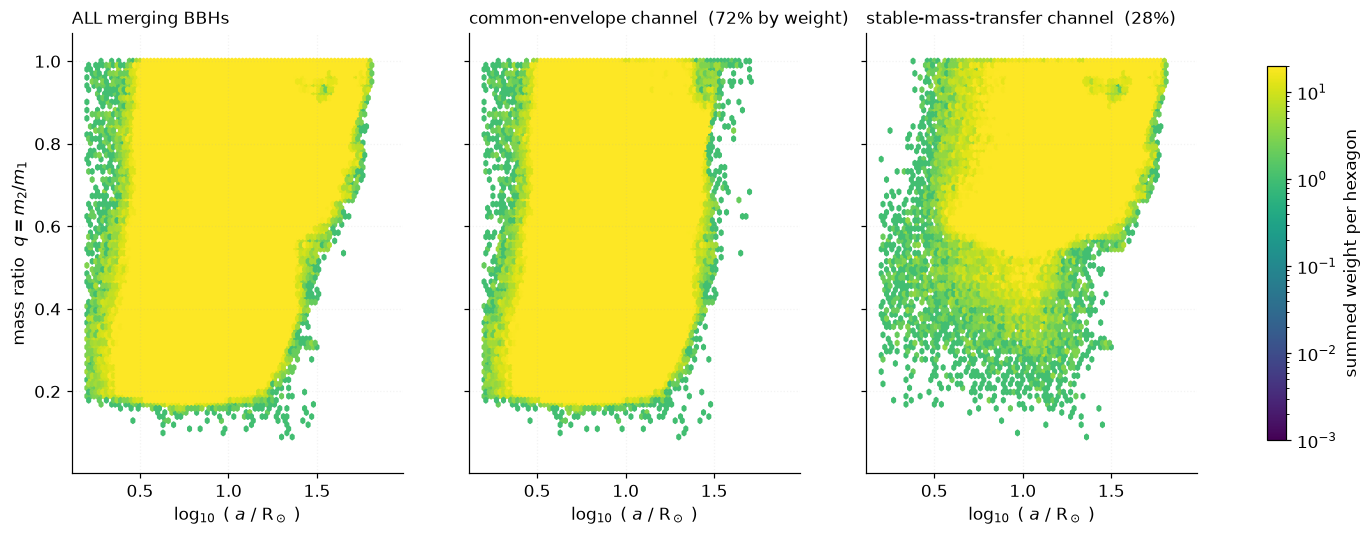

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), sharex=True, sharey=True)

# The SAME colour map and the SAME normalisation in all three panels, so that equal
# colour means equal weight and the panels can honestly be compared by eye.
panels = [
    (bbh, "ALL merging BBHs"),
    (bbh[ce_mask],  f"common-envelope channel  ({100*bbh.w[ce_mask].sum()/bbh.w.sum():.0f}% by weight)"),
    (bbh[smt_mask], f"stable-mass-transfer channel  ({100*bbh.w[smt_mask].sum()/bbh.w.sum():.0f}%)"),
]

for ax, (d, title) in zip(axes, panels):
    hb = ax.hexbin(d.log_a, d.q,
                   gridsize=85, extent=(0.2, 1.9, 0.05, 1.02), mincnt=1,
                   norm=LogNorm(vmin=1e-3, vmax=20), cmap="viridis")
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel(r"$\log_{10}$ ( $a$ / R$_\odot$ )")
    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"mass ratio  $q = m_2/m_1$")
fig.colorbar(hb, ax=axes, shrink=0.85, label="summed weight per hexagon")
plt.show()

### **Discussion**

Without the weights, the two-island structure is lost. The left panel is dominated by uniform counts, making the CE and SMT populations blend together rather than appear as two distinct structures.

From the unweighted figure, the merging BBHs occupy a single broad, continuous region of parameter space and the two formation channels are not distinguishable.

# Exercise 6

## Two common envelops

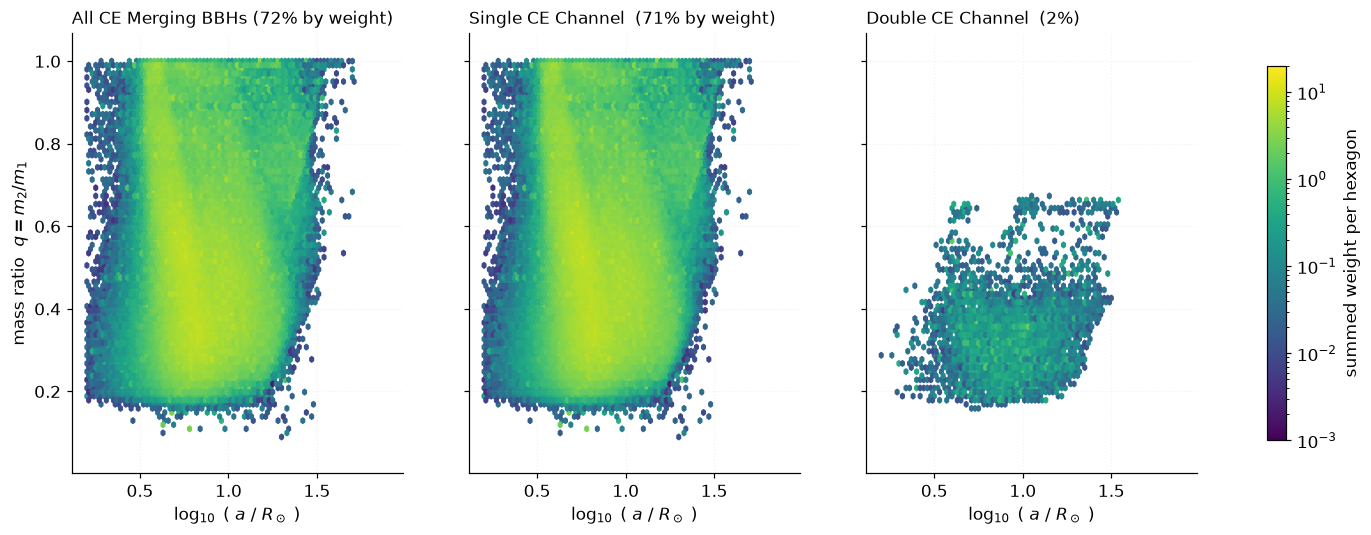

In [26]:
ce1_mask  = bbh.n_CE == 1      
ce2_mask = bbh.n_CE == 2 

fig,axes = plt.subplots(1, 3, figsize=(16.5, 5.2), sharex=True, sharey=True)

# The SAME colour map and the SAME normalisation in all three panels, so that equal
# colour means equal weight and the panels can honestly be compared by eye.
panels = [
    (bbh[ce_mask], f"All CE Merging BBHs ({100*bbh.w[ce_mask].sum()/bbh.w.sum():.0f}% by weight)"),
    (bbh[ce1_mask],  f"Single CE Channel  ({100*bbh.w[ce1_mask].sum()/bbh.w.sum():.0f}% by weight)"),
    (bbh[ce2_mask], f"Double CE Channel  ({100*bbh.w[ce2_mask].sum()/bbh.w.sum():.0f}%)"),
]

for ax, (d, title) in zip(axes, panels):
    hb = ax.hexbin(d.log_a, d.q, C=d.w, reduce_C_function=np.sum,
                   gridsize=85, extent=(0.2, 1.9, 0.05, 1.02), mincnt=1,
                   norm=LogNorm(vmin=1e-3, vmax=20), cmap="viridis")
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel(r"$\log_{10}$ ( $a$ / $R_\odot$ )")
    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"mass ratio  $q = m_2/m_1$")
fig.colorbar(hb, ax=axes, shrink=0.85, label="summed weight per hexagon")
plt.show()

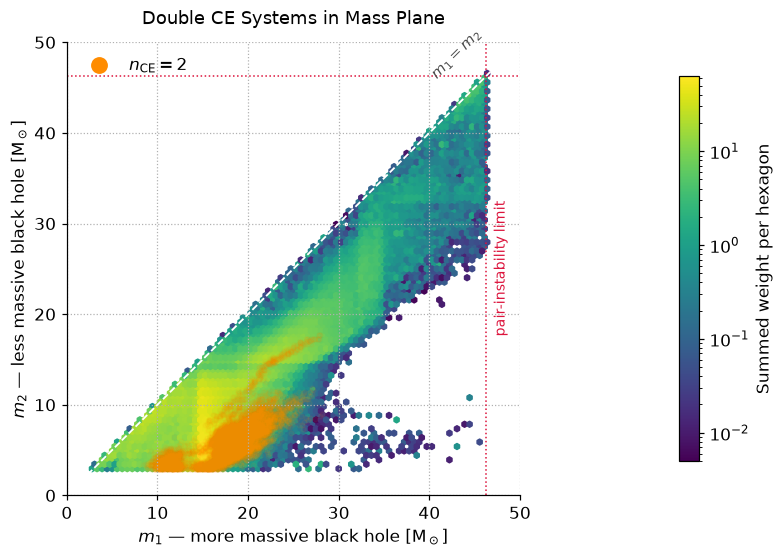

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.2))

# ---Mass Plane---

hb = ax.hexbin(bbh.m1, bbh.m2, C=bbh.w, reduce_C_function=np.sum,
                  gridsize=90, extent=(0, 50, 0, 50), mincnt=1,
                  norm=LogNorm(), cmap='viridis')
cb = fig.colorbar(hb, ax=ax, location='right', pad=0.15, shrink=0.85)
cb.set_label('Summed weight per hexagon')

ax.plot([0,50], [0,50], color='white', lw=1.2, ls='--')
ax.text(43, 46, r"$m_1 = m_2$", color="0.3", fontsize=10, ha="center", rotation=45)

m_lim = bbh.m1[bbh.m1 < 100].max()
ax.axvline(m_lim, color="crimson", lw=1, ls=":")
ax.axhline(m_lim, color="crimson", lw=1, ls=":")
ax.text(m_lim + 0.8, 25, "pair-instability limit", color="crimson", fontsize=9,
        rotation=90, va="center")

# Overlay: n_CE = 2
ax.scatter(bbh[ce2_mask].m1, bbh[ce2_mask].m2,
    c="darkorange", s=10, alpha=0.05, label=r"$n_{\rm CE}=2$")

ax.set_xlabel(r"$m_1$ — more massive black hole [M$_\odot$]")
ax.set_ylabel(r"$m_2$ — less massive black hole [M$_\odot$]")
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
ax.set_aspect("equal")
ax.grid(alpha=1)
ax.set_title("Double CE Systems in Mass Plane", fontsize=12, y=1.02)


legend_handle = Line2D([0], [0], marker='o', color='w',
                markerfacecolor='darkorange', markeredgecolor='darkorange',
                markersize=10, label=r'$n_{\rm CE}=2$')

ax.legend(handles=[legend_handle], loc='upper left', )

plt.tight_layout()
plt.show()

### **Discussion**

The systems with two CE events (n_CE = 2) do not form a third island in the **$log_{10}a--q$** plane. They only constitute only about 2% of the merging BBH population by statistical weight, as shown in the third panel graph. Their distribution is concentrated mainly around $$0.6 \lesssim log_{10}(a/R{\odot}) \lesssim 1.5$$ and $0.2 \lesssim q \lesssim 0.45$ with a smaller population extending toward $q \sim 0.6$. Thus, the double-CE systems occupy a considerably more restricted region of parameter space and are predominatly **unequal-mass binaries.**

In the m1-m2 plane, the double-CE systems do not appear to define an obviously distinct mass island. They lie within the broader BBH mass distribution with characteristic masses generally occupying the lower-to-intermediate part of the BBH population. Thus, the mass plane isn't that informative compared to log a - q plane.

Physically, two CE episodes becomes binary to survive the first unstable mass-transfer episode and subsequently undergo another unstable mass-transfer episode when the companion evolves. The first CE alters the orbit and the structure, while the later CE shrink the orbit further. So, double-CE systems represent a relatively uncommon evolutionary pathway and form a very small part of BBH population.